In [1]:
# replication of k3 ortholog screen

In [1]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from matplotlib import ticker

In [2]:
input_file = '../../results/barseq/replicates_all-reads_241011.csv'
df = pd.read_csv(input_file)

/var/folders/2_/3s1x89754mb6ctqh_1rrl4mc0000gn/T/ipykernel_76819/3272115104.py:2: DtypeWarning: Columns (7,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


In [3]:
# remove variants at sites of non-interest
pkr_range = [(255,278),(371,385),(448,455),(480,506)]
pkr_sites = []

for i, (start, end) in enumerate(pkr_range):
    for site in range(start, end+1):
        pkr_sites.append(site)

df_wt = df.query('pkr == "PKR-WT"')
temp_df = df.query('pkr != "PKR-WT"')
temp_df.dropna(subset=['site'], inplace=True)
temp_df['site'] = temp_df['site'].astype(int)
df_vars = temp_df[temp_df['site'].isin(pkr_sites)]

df = pd.concat([df_wt,df_vars])

/var/folders/2_/3s1x89754mb6ctqh_1rrl4mc0000gn/T/ipykernel_76819/656947461.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.dropna(subset=['site'], inplace=True)
/var/folders/2_/3s1x89754mb6ctqh_1rrl4mc0000gn/T/ipykernel_76819/656947461.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['site'] = temp_df['site'].astype(int)


In [4]:
# purify to designed pkr variants
input_file = '../../data/dms_primers/pkr_variants_list.pkl'
with open(input_file, 'rb') as f:
    designed_variant_list = pickle.load(f)
designed_variant_list = ["PKR-" + variant for variant in designed_variant_list]
designed_variant_list.append("PKR-WT")
df = df[df['pkr'].isin(designed_variant_list)]

In [5]:
# add pkr type
def pkr_type(x, pkr_stop = 551):
    if x[-1] == "*" and int(x.split('-')[1][1:-1]) < pkr_stop:
        return "Nonsense"
    elif x[-2:] == 'WT':
        return "WT"
    else:
        return 'Variant'
df['pkr_type'] = df['pkr'].apply(pkr_type)

In [6]:
# apply read threshold
threshold = 50
df = df[df['0hr'] >= threshold]

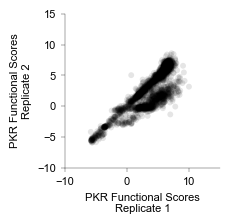

Pearson correlation coefficient: 0.8563736762199612
Spearman correlation coefficient: 0.8324938380712529


In [8]:
# all data, between R1 and R2
temp_df = df.groupby(['replicate','k3','pkr'])['auc'].mean().reset_index()
temp_df = temp_df.pivot_table(index=['pkr','k3'], columns='replicate', values='auc').reset_index()
temp_df = temp_df[~temp_df.isin([np.inf, -np.inf]).any(axis=1)]
temp_df = temp_df.dropna()
temp_df

width_in = 2
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = .1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
plt.figure(figsize=(width_in, height_in)) # save size

ax = sns.scatterplot(
    data=temp_df,
    x='Replicate 1',
    y='Replicate 2',
    color='black',
    alpha=alpha_val,
    size=marker_diameter,
    legend=False,
    edgecolor='none',
)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set x and y limits
ax.set_xlim(-10, 15)
ax.set_ylim(-10, 15)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel('PKR Functional Scores\nReplicate 1', fontsize=font_size, fontname=font_name)
ax.set_ylabel('PKR Functional Scores\nReplicate 2', fontsize=font_size, fontname=font_name)

#plt.tight_layout()
fig = ax.get_figure()
#fig.savefig(f'../../img/replication/whole-experiment_{width_in}x{height_in}.svg', format='svg', bbox_inches='tight', transparent=False)
plt.show()

# Calculate Pearson correlation
pearson_corr, _ = pearsonr(temp_df['Replicate 1'], temp_df['Replicate 2'])
print("Pearson correlation coefficient:", pearson_corr)

# Calculate Spearman correlation
spearman_corr, _ = spearmanr(temp_df['Replicate 1'], temp_df['Replicate 2'])
print("Spearman correlation coefficient:", spearman_corr)

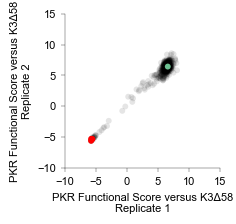

Pearson correlation coefficient: 0.9789948554193997
Spearman correlation coefficient: 0.6593958524433893


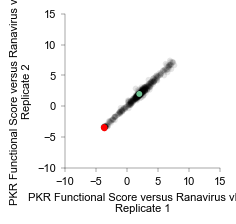

Pearson correlation coefficient: 0.9933663065492321
Spearman correlation coefficient: 0.9792031631264351


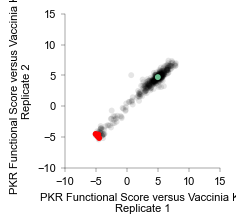

Pearson correlation coefficient: 0.9831385587933514
Spearman correlation coefficient: 0.928529529069107


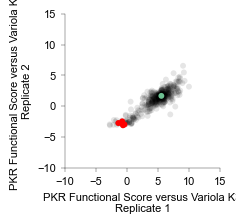

Pearson correlation coefficient: 0.8888603871303943
Spearman correlation coefficient: 0.7889830236671008


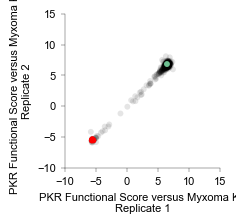

Pearson correlation coefficient: 0.9940429540052265
Spearman correlation coefficient: 0.6891904530657026


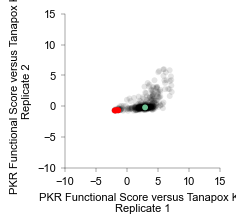

Pearson correlation coefficient: 0.5717937387913001
Spearman correlation coefficient: 0.5928570357980059


In [10]:
# generate a figure for each k3 condition
k3_cond_list = ['K3Δ58', 'RCVZ vIF2α', 'VACV K3', 'VARV C3','MYXV M156R','TPV K3']
k3_names = ['K3Δ58', 'Ranavirus vIF2α', 'Vaccinia K3', 'Variola K3', 'Myxoma K3', 'Tanapox K3']
for k3,k3_name in zip(k3_cond_list,k3_names):
    temp_df = df.query('k3 == @k3')
    temp_df = temp_df.groupby(['replicate','k3','pkr','pkr_type'])['auc'].mean().reset_index()
    temp_df = temp_df.pivot_table(index=['pkr','k3','pkr_type'], columns='replicate', values='auc').reset_index()
    temp_df = temp_df[~temp_df.isin([np.inf, -np.inf]).any(axis=1)]
    temp_df = temp_df.dropna()
    temp_df
    
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .1
    marker_diameter = 3 # 1.75
    
    font = {'family': font_name, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size
    
    ax = sns.scatterplot(
        data=temp_df,
        x='Replicate 1',
        y='Replicate 2',
        color='black',
        alpha=alpha_val,
        size=3,
        legend=False,
        edgecolor='none',
    )

    # plot wt 
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "WT"'),
        x='Replicate 1',
        y='Replicate 2',
        color='#6dc091',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )
    
    # plot nonsense mutations
    nonsense_vars = ["PKR-S275*","PKR-Q376*","PKR-R453*","PKR-E480*"]
    ax = sns.scatterplot(
        data=temp_df.query('pkr.isin(@nonsense_vars)'),
        x='Replicate 1',
        y='Replicate 2',
        color='red',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)
    
    # Set x and y limits
    ax.set_xlim(-10, 15)
    ax.set_ylim(-10, 15)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)
    
    # Set font properties for axis labels
    ax.set_xlabel(f'PKR Functional Score versus {k3_name}\nReplicate 1', fontsize=font_size, fontname=font_name)
    ax.set_ylabel(f'PKR Functional Score versus {k3_name}\nReplicate 2', fontsize=font_size, fontname=font_name)
    
    # Set tick marks and labels every 5 units
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    
    #plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(f'../../img/replication/replication_{k3_name}_wt-nonsense.svg', format='svg', bbox_inches='tight', transparent=False)
    plt.show()
    
    # Calculate Pearson correlation
    pearson_corr, _ = pearsonr(temp_df['Replicate 1'], temp_df['Replicate 2'])
    print("Pearson correlation coefficient:", pearson_corr)
    
    # Calculate Spearman correlation
    spearman_corr, _ = spearmanr(temp_df['Replicate 1'], temp_df['Replicate 2'])
    print("Spearman correlation coefficient:", spearman_corr)

In [29]:
# generate a figure for each k3 condition
k3_cond_list = ['VACV K3']
k3_names = ['Vaccinia K3']
for k3,k3_name in zip(k3_cond_list,k3_names):
    temp_df = df.query('k3 == @k3')
    temp_df = temp_df.groupby(['replicate','k3','pkr','pkr_type'])['auc'].mean().reset_index()
    temp_df = temp_df.pivot_table(index=['pkr','k3','pkr_type'], columns='replicate', values='auc').reset_index()
    temp_df = temp_df[~temp_df.isin([np.inf, -np.inf]).any(axis=1)]
    temp_df = temp_df.dropna()
    temp_df

In [32]:
nonsense_vars = ["PKR-S275*","PKR-Q376*","PKR-R453*","PKR-E480*"]
temp_df.query('pkr.isin(@nonsense_vars)')

replicate,pkr,k3,pkr_type,Replicate 1,Replicate 2
313,PKR-Q376*,VACV K3,Nonsense,2.433665,-0.301899
336,PKR-R453*,VACV K3,Nonsense,0.422050,-1.086005
346,PKR-S275*,VACV K3,Nonsense,2.015328,-0.684886


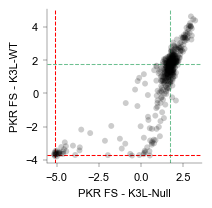

In [88]:
input_file = '../../results/barseq/combined_grouped-barcodes_240212.csv'
df = pd.read_csv(input_file)

def pkr_type(x, pkr_stop = 551):
    if x[-1] == "*" and int(x.split('-')[1][1:-1]) < pkr_stop:
        return "Nonsense"
    elif x[-2:] == 'WT':
        return "WT"
    else:
        return 'Variant'
df['pkr_type'] = df['pkr'].apply(pkr_type)

temp_df = df.pivot_table(index='pkr', columns='k3', values='auc_mean').reset_index()

width_in = 2
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = 1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
plt.figure(figsize=(width_in, height_in)) # save size

ax = sns.scatterplot(
    data=temp_df,
    x='K3L-Null',
    y='K3L-WT',
    color='black',
    alpha=.2,
    size=3,
    legend=False,
    edgecolor='none',
)

# vertical K3L-Null dashed lines
v_non = df.query('pkr_type == "Nonsense" and k3 == "K3L-Null"')['auc_mean'].mean()
v_wt = df.query('k3 == "K3L-Null" and pkr == "PKR-WT"')['auc_mean'].values[0]
ax.axvline(x=v_non, color='red', linestyle='--', linewidth=.75, zorder=0)
ax.axvline(x=v_wt, color='#6dc091', linestyle='--', linewidth=.75, zorder=0)

# horizontal K3L-WT dashed lines
h_non = df.query('pkr_type == "Nonsense" and k3 == "K3L-WT"')['auc_mean'].mean()
h_wt = df.query('k3 == "K3L-WT" and pkr == "PKR-WT"')['auc_mean'].values[0]
ax.axhline(y=h_non, color='red', linestyle='--', linewidth=.75, zorder=0)
ax.axhline(y=h_wt, color='#6dc091', linestyle='--', linewidth=.75, zorder=0)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set x and y limits
#ax.set_xlim(-6, 10)
#ax.set_ylim(-6, 10)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel('PKR FS - K3L-Null', fontsize=font_size, fontname=font_name)
ax.set_ylabel('PKR FS - K3L-WT', fontsize=font_size, fontname=font_name)


#plt.tight_layout()
fig = ax.get_figure()
fig.savefig(f'../../img/pkr_replication/k3-null-wt_{width_in}x{height_in}.svg', format='svg')
plt.show()


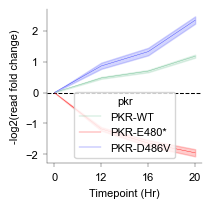

In [85]:
# AUC curve example
input_file = '../../results/barseq/combined_variant-reads_240212.csv'
df = pd.read_csv(input_file)

def pkr_type(x, pkr_stop = 551):
    if x[-1] == "*" and int(x.split('-')[1][1:-1]) < pkr_stop:
        return "Nonsense"
    elif x[-2:] == 'WT':
        return "WT"
    else:
        return 'Variant'
df['pkr_type'] = df['pkr'].apply(pkr_type)

df

temp_df = df.melt(id_vars=['pkr','pkr_type','k3'], value_vars=['0hr_-log2fc','12hr_-log2fc','16hr_-log2fc','20hr_-log2fc'], var_name='-log2(FC) TP', value_name='PKR FS - K3L-WT')
temp_df = temp_df.query('k3 == "K3L-WT"')
example_pkr = ['PKR-E480*','PKR-WT','PKR-D486V']
temp_df = temp_df[temp_df['pkr'].isin(example_pkr)]
map_vals = {'0hr_-log2fc':'0', '12hr_-log2fc':'12', '16hr_-log2fc':'16', '20hr_-log2fc':'20'}
temp_df['Timepoint (Hr)'] = temp_df['-log2(FC) TP'].map(map_vals)

width_in = 2
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = 1
marker_diameter = 3 # 1.75

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)
plt.figure(figsize=(width_in, height_in)) # save size

ax = sns.lineplot(
    data=temp_df,
    x='Timepoint (Hr)',
    y='PKR FS - K3L-WT',
    hue='pkr',
    palette={'PKR-WT':'#6dc091', 'PKR-E480*':'red', 'PKR-D486V':'#272Efa'},
    hue_order = ['PKR-WT','PKR-E480*','PKR-D486V']
)

ax.axhline(y=0, color='black', linestyle='--', linewidth=.75, zorder=0)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel('Timepoint (Hr)', fontsize=font_size, fontname=font_name)
ax.set_ylabel('-log2(read fold change)', fontsize=font_size, fontname=font_name)


#plt.tight_layout()
fig = ax.get_figure()
fig.savefig(f'../../img/pkr_replication/auc_{width_in}x{height_in}.svg', format='svg')
plt.show()